## Importing Libraries

In [34]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
%matplotlib inline

## Loading Datasets

In [35]:
genome_scores = pd.read_csv("../data/raw/processed/genome_scores.csv", index_col = 0)
genome_scores.head()

,movie_id,tag_id,relevance
0,1,1,0.03200
1,1,2,0.02225
2,1,3,0.07000
3,1,4,0.05900
4,1,5,0.12300


In [32]:
genome_scores.shape

(17252760, 3)

In [36]:
genome_scores = genome_scores.pivot_table(index = "movie_id", columns = "tag_id", values = "relevance")
genome_scores

tag_id,1,2,3,4,5,6,7,8,9,10,...,1119,1120,1121,1122,1123,1124,1125,1126,1127,1128
movie_id,,,,,,,,,,,,,,,,,,,,,
1,0.03200,0.02225,0.07000,0.05900,0.12300,0.13100,0.06175,0.19550,0.26625,0.03300,...,0.04125,0.01550,0.03775,0.03500,0.11525,0.04350,0.04050,0.03300,0.07700,0.01825
2,0.03250,0.03200,0.04050,0.05100,0.10050,0.06350,0.19825,0.07525,0.09750,0.06325,...,0.04100,0.02025,0.01100,0.01875,0.13425,0.01850,0.01825,0.00825,0.08750,0.01375
3,0.04150,0.05525,0.02125,0.07225,0.05125,0.04400,0.03000,0.10375,0.02300,0.03250,...,0.06175,0.01825,0.02375,0.01700,0.12400,0.02775,0.01600,0.01325,0.10075,0.01800
4,0.03150,0.03400,0.02800,0.02725,0.06475,0.03325,0.02700,0.06900,0.03950,0.02525,...,0.06175,0.02350,0.01825,0.03075,0.17725,0.03950,0.01925,0.01100,0.10225,0.01375
5,0.03950,0.05200,0.02575,0.04475,0.07300,0.05375,0.02100,0.05050,0.01875,0.02225,...,0.05575,0.01750,0.01550,0.01650,0.17750,0.01975,0.01875,0.00900,0.09050,0.01475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286901,0.03425,0.03550,0.03975,0.02800,0.11725,0.06400,0.06875,0.11100,0.20500,0.02425,...,0.06475,0.02250,0.01750,0.03325,0.21375,0.05450,0.12725,0.01900,0.07625,0.01500
286905,0.07525,0.07800,0.12050,0.04250,0.20975,0.08500,0.10650,0.08650,0.08700,0.06800,...,0.05500,0.03225,0.04775,0.05700,0.20075,0.07150,0.03000,0.05550,0.09475,0.02375
287377,0.06250,0.05800,0.06575,0.12250,0.19625,0.10200,0.03300,0.17575,0.09800,0.03350,...,0.03850,0.03000,0.02050,0.05750,0.22900,0.04475,0.07900,0.00800,0.13250,0.03525


## Kmeans model

We have prepared the dataset, so know we have to fit our model and try it.

In [7]:
kmeans = KMeans(n_clusters = 50,random_state = 23)

In [8]:
kmeans.fit(genome_scores)

,n_clusters,50
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,23
,copy_x,True
,algorithm,'lloyd'


In [10]:
clusters = kmeans.predict(genome_scores)

In [18]:
clusters

array([31, 38, 33, ..., 23, 24, 23], shape=(16376,), dtype=int32)

In [13]:
pd.Series(clusters).value_counts().head(10)

46    994
33    872
20    658
24    624
8     523
25    518
10    507
5     464
18    440
37    427
Name: count, dtype: int64

In [29]:
K = range(2, 20)
inertia = []
for i in K:
    kmeans = KMeans(n_clusters=i,
        init="random",
        n_init=100,  # try with 1, 4, 8, 20, 30, 100...
        max_iter=300,
        tol=0,
        algorithm="elkan",
        random_state=23)
    kmeans.fit(genome_scores)
    inertia.append(kmeans.inertia_)

Text(0.5, 1.0, 'Elbow Method showing the optimal k')

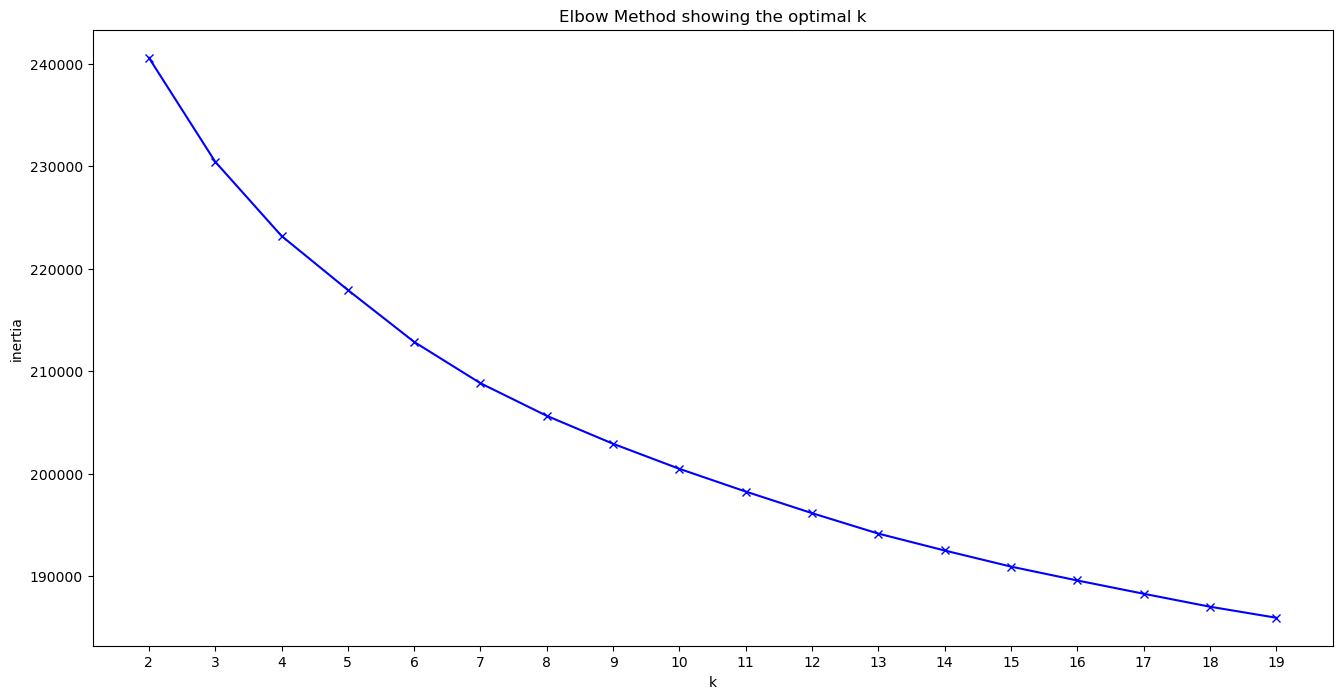

In [31]:
plt.figure(figsize=(16,8))
plt.plot(K, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('inertia')
plt.xticks(np.arange(min(K), max(K)+1, 1.0))
plt.title('Elbow Method showing the optimal k')

## PCA

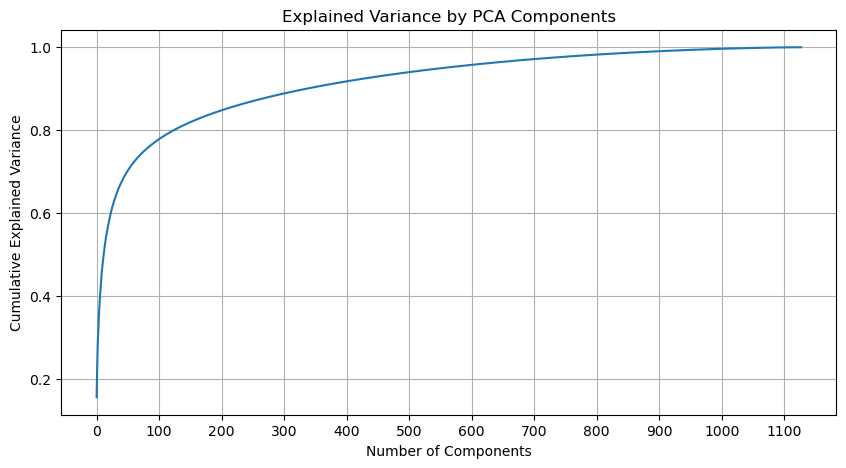

In [14]:
pca = PCA()
pca.fit(genome_scores)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10,5))
plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(range(0,1200,100))
plt.title("Explained Variance by PCA Components")
plt.grid()
plt.show()

We'll be trying with 200 and 150.

In [15]:
pca_200 = PCA(n_components = 200,
              random_state = 23)

genome_reduced = pca_200.fit_transform(genome_scores)

In [37]:
pca_150 = PCA(n_components = 150,
              random_state = 23)

genome_reduced_150 = pca_150.fit_transform(genome_scores)

In [6]:
pca_50 = PCA(n_components = 50,
              random_state = 23)

genome_reduced_50 = pca_50.fit_transform(genome_scores)

## KMeans with PCA(200)

In [17]:
K = [30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 500, 1000]
inertia = []
for i in K:
    kmeans = KMeans(n_clusters=i,
        init="random",
        n_init=20,  # try with 1, 4, 8, 20, 30, 100...
        max_iter=300,
        tol=0,
        algorithm="elkan",
        random_state=23)
    kmeans.fit(genome_reduced)
    inertia.append(kmeans.inertia_)

KeyboardInterrupt: 

Text(0.5, 1.0, 'Elbow Method showing the optimal k')

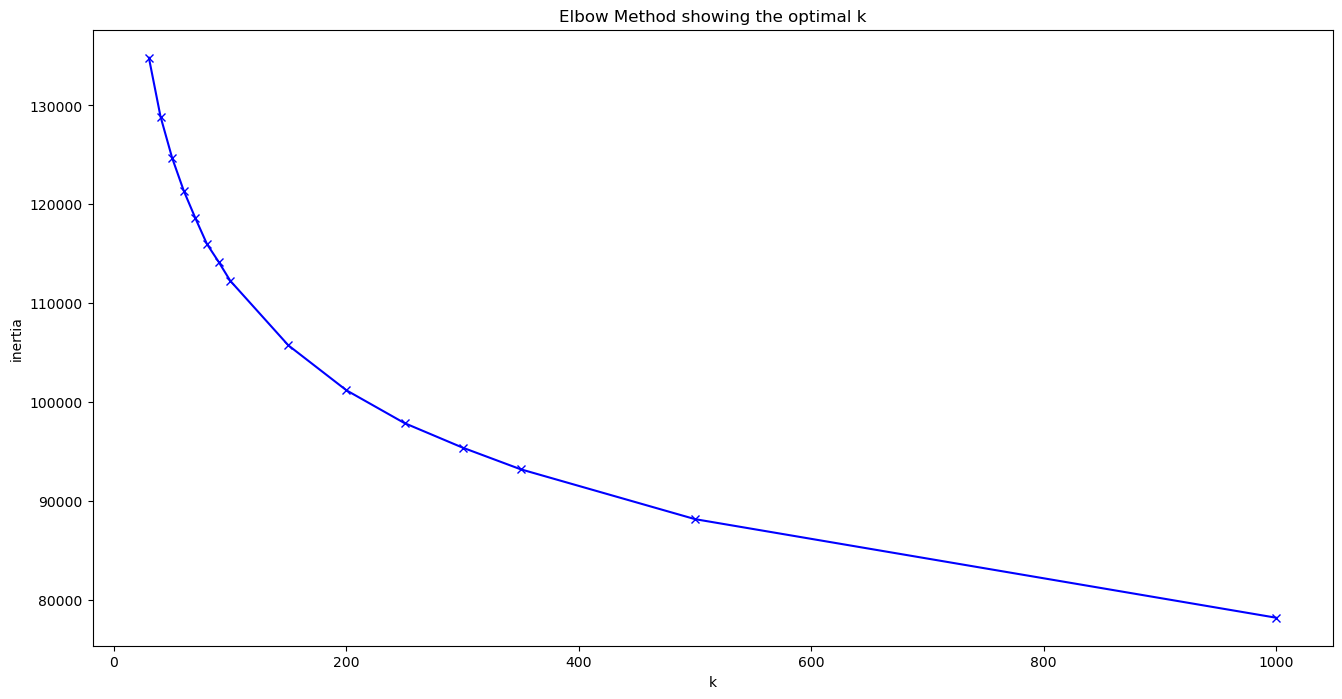

In [22]:
plt.figure(figsize=(16,8))
plt.plot(K, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('inertia')
#plt.xticks(np.arange(min(K), max(K)+1, 1.0))
plt.title('Elbow Method showing the optimal k')

In [18]:
kmeans = KMeans(n_clusters = 100,random_state = 23)
kmeans.fit(genome_reduced)
clusters1 = kmeans.predict(genome_reduced)

In [19]:
pd.Series(clusters1).value_counts().describe()

count    100.000000
mean     163.760000
std      101.095327
min       50.000000
25%       99.250000
50%      140.500000
75%      185.750000
max      614.000000
Name: count, dtype: float64

In [20]:
kmeans = KMeans(n_clusters = 200,random_state = 23)
kmeans.fit(genome_reduced)
clusters2 = kmeans.predict(genome_reduced)

In [21]:
pd.Series(clusters2).value_counts().describe()

count    200.0000
mean      81.8800
std       50.6375
min       10.0000
25%       48.0000
50%       70.5000
75%      100.0000
max      330.0000
Name: count, dtype: float64

## KMeans with PCA(150)

In [43]:
K = [30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 500, 1000]
inertia = []
for i in K:
    kmeans = KMeans(n_clusters=i,
        init="random",
        n_init=20,  # try with 1, 4, 8, 20, 30, 100...
        max_iter=300,
        tol=0,
        algorithm="elkan",
        random_state=23)
    kmeans.fit(genome_reduced_150)
    inertia.append(kmeans.inertia_)

Text(0.5, 1.0, 'Elbow Method showing the optimal k')

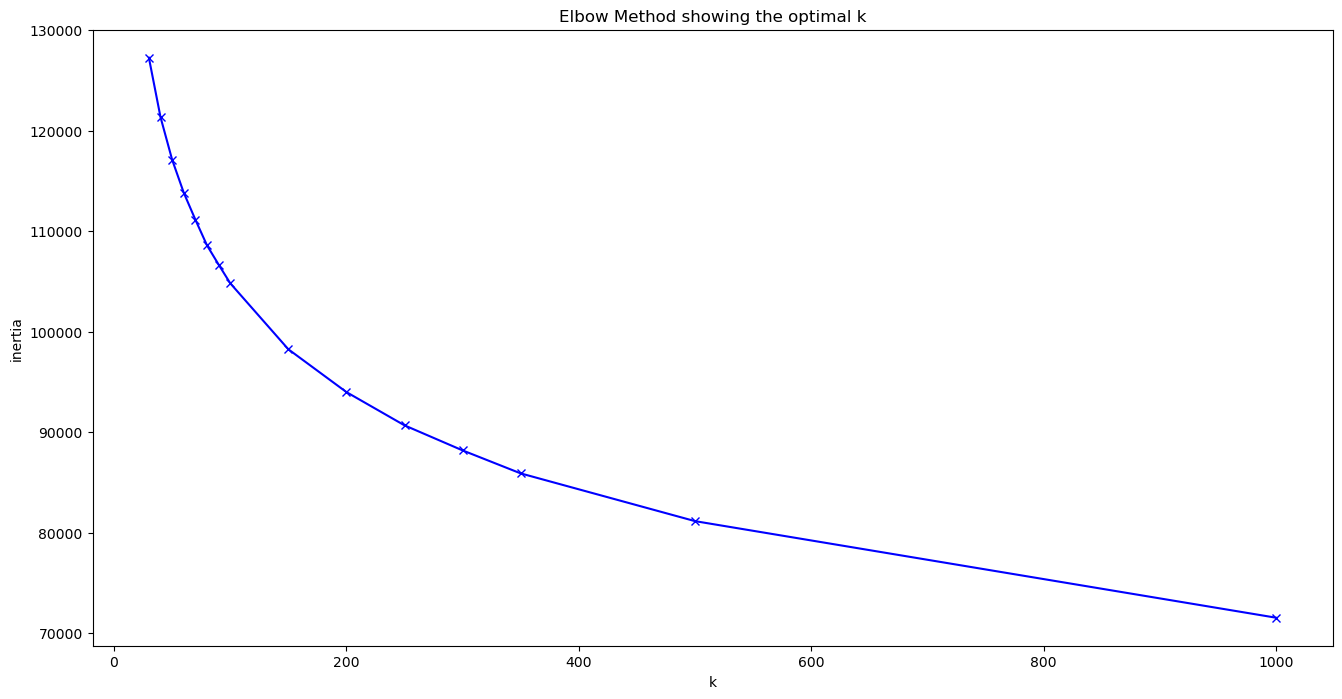

In [44]:
plt.figure(figsize=(16,8))
plt.plot(K, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('inertia')
#plt.xticks(np.arange(min(K), max(K)+1, 1.0))
plt.title('Elbow Method showing the optimal k')

In [22]:
kmeans = KMeans(n_clusters = 100,random_state = 23)
kmeans.fit(genome_reduced_150)
clusters1 = kmeans.predict(genome_reduced_150)

In [23]:
pd.Series(clusters1).value_counts().describe()

count    100.000000
mean     163.760000
std       90.776462
min       43.000000
25%      107.250000
50%      142.500000
75%      182.750000
max      562.000000
Name: count, dtype: float64

In [6]:
kmeans = KMeans(n_clusters = 200,random_state = 23)
kmeans.fit(genome_reduced_150)
clusters2 = kmeans.predict(genome_reduced_150)

In [9]:
pd.Series(clusters2).value_counts().describe()

count    200.000000
mean      81.880000
std       49.207239
min       15.000000
25%       48.000000
50%       70.000000
75%      104.000000
max      292.000000
Name: count, dtype: float64

In [38]:
kmeans = KMeans(n_clusters = 150,random_state = 23)
kmeans.fit(genome_reduced_150)
clusters3 = kmeans.predict(genome_reduced_150)

In [39]:
pd.Series(clusters3).value_counts().describe()

count    150.000000
mean     101.966667
std       61.812600
min       19.000000
25%       64.500000
50%       88.000000
75%      126.000000
max      378.000000
Name: count, dtype: float64

## Create Clusters' column

In [42]:
genome_scores["cluster"] = kmeans.labels_
genome_scores.head(10)

tag_id,1,2,3,4,5,6,7,8,9,10,...,1120,1121,1122,1123,1124,1125,1126,1127,1128,cluster
movie_id,,,,,,,,,,,,,,,,,,,,,
1,0.03200,0.02225,0.07000,0.05900,0.12300,0.13100,0.06175,0.19550,0.26625,0.03300,...,0.01550,0.03775,0.03500,0.11525,0.04350,0.04050,0.03300,0.07700,0.01825,149
2,0.03250,0.03200,0.04050,0.05100,0.10050,0.06350,0.19825,0.07525,0.09750,0.06325,...,0.02025,0.01100,0.01875,0.13425,0.01850,0.01825,0.00825,0.08750,0.01375,17
3,0.04150,0.05525,0.02125,0.07225,0.05125,0.04400,0.03000,0.10375,0.02300,0.03250,...,0.01825,0.02375,0.01700,0.12400,0.02775,0.01600,0.01325,0.10075,0.01800,107
4,0.03150,0.03400,0.02800,0.02725,0.06475,0.03325,0.02700,0.06900,0.03950,0.02525,...,0.02350,0.01825,0.03075,0.17725,0.03950,0.01925,0.01100,0.10225,0.01375,89
5,0.03950,0.05200,0.02575,0.04475,0.07300,0.05375,0.02100,0.05050,0.01875,0.02225,...,0.01750,0.01550,0.01650,0.17750,0.01975,0.01875,0.00900,0.09050,0.01475,107
6,0.02975,0.02200,0.02575,0.04675,0.07750,0.07550,0.04925,0.22300,0.11275,0.03100,...,0.02250,0.01500,0.06500,0.11850,0.09550,0.05150,0.01250,0.10375,0.02600,20
7,0.03175,0.03475,0.09775,0.07625,0.09325,0.09275,0.03825,0.06475,0.02875,0.08825,...,0.02925,0.01100,0.03050,0.15625,0.05200,0.02025,0.00775,0.07025,0.01275,89
8,0.02750,0.03750,0.05725,0.03475,0.07100,0.02550,0.01925,0.04900,0.02100,0.08975,...,0.02075,0.01100,0.01400,0.30825,0.03225,0.01900,0.00625,0.08825,0.01400,82
9,0.03000,0.04100,0.02325,0.01800,0.03200,0.01175,0.01450,0.04025,0.01000,0.01425,...,0.01050,0.00750,0.01225,0.14250,0.01125,0.02025,0.00425,0.11200,0.01775,110


In [43]:
cluster_df = genome_scores[["cluster"]]
cluster_df

tag_id,cluster
movie_id,
1,149
2,17
3,107
4,89
5,107
...,...
286901,21
286905,21
287377,21


In [44]:
cluster_df.to_csv("../data/processed/clusters.csv")

## Create Suggestions System

In [16]:
def random_film(movieid, cluster_df = cluster_df):
    cluster = cluster_df.loc[movieid, "cluster"]

    candidates = cluster_df.index[
        (cluster_df["cluster"] == cluster) &
        (cluster_df.index != movieid)
    ]

    return np.random.choice(candidates)

In [17]:
random_film(158966)

np.int64(219003)